Importación de librerías y montaje de Google Drive

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Carga y lectura de la base de datos

In [3]:
# Modifica esta ruta según la ubicación de tu archivo insurance.csv en Google Drive
ruta = "/content/drive/MyDrive/semestre 6/sist int/student-mat.csv"

df = pd.read_csv(ruta)
print("Base de datos cargada correctamente")

Base de datos cargada correctamente


Exploración inicial y tamaño del DataFrame

In [4]:
print("--- PRIMEROS REGISTROS ---")
print(df.head())

print("\n--- NOMBRES DE LAS COLUMNAS ---")
print(df.columns.tolist())

print("\n--- TAMAÑO DE LA BASE DE DATOS ---")
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

--- PRIMEROS REGISTROS ---
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]

--- NOMBRES DE LAS COLUMNAS ---
['school', 'sex', 'age', 'ad

Detección de valores faltantes (nulos)

In [5]:
print("--- CANTIDAD DE VALORES FALTANTES POR COLUMNA ---")
print(df.isna().sum())

print("\n--- PORCENTAJE DE VALORES FALTANTES ---")
porcentaje_faltantes = df.isna().mean() * 100
print(porcentaje_faltantes)

# Visualizar las filas que contienen algún valor nulo
df_nulos = df[df.isna().any(axis=1)]
print(f"\nTotal de filas con al menos un nulo: {len(df_nulos)}")

--- CANTIDAD DE VALORES FALTANTES POR COLUMNA ---
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

--- PORCENTAJE DE VALORES FALTANTES ---
school        0.0
sex           0.0
age           0.0
address       0.0
famsize       0.0
Pstatus       0.0
Medu          0.0
Fedu          0.0
Mjob          0.0
Fjob          0.0
reason        0.0
guardian      0.0
traveltime    0.0
studytime     0.0
failures      0.0
schoolsup     0.0
famsup        0.0
paid          0.0
activities    0.0
nursery       0.0
higher  

Identificación y eliminación de filas duplicadas

In [6]:
print("--- ANÁLISIS DE DUPLICADOS ---")
num_duplicados = df.duplicated().sum()
print(f"Número de filas duplicadas: {num_duplicados}")

if num_duplicados > 0:
    print("\nVisualizando duplicados:")
    print(df[df.duplicated(keep=False)])

    # Eliminación de duplicados
    df_sin_duplicados = df.drop_duplicates()
    print(f"\nTamaño original: {df.shape}")
    print(f"Tamaño sin duplicados: {df_sin_duplicados.shape}")
else:
    df_sin_duplicados = df.copy()
    print("No se encontraron filas duplicadas.")

--- ANÁLISIS DE DUPLICADOS ---
Número de filas duplicadas: 0
No se encontraron filas duplicadas.


Tratamiento e imputación de valores faltantes

In [7]:
# Creamos una copia de trabajo limpia a partir de la base sin duplicados
df_base = df_sin_duplicados.copy()

# Estrategia de imputación para columnas numéricas (si aplicara)
columnas_numericas = df_base.select_dtypes(include=[np.number]).columns

# Imputación por Mediana en las variables numéricas
df_imputado = df_base.copy()
for col in columnas_numericas:
    if df_imputado[col].isna().sum() > 0:
        mediana_val = df_imputado[col].median()
        df_imputado[col] = df_imputado[col].fillna(mediana_val)
        print(f"Imputado valor nulo en {col} con la mediana: {mediana_val}")

print("\nComprobación de nulos tras imputación:")
print(df_imputado.isna().sum())

# Definimos df_limpio como la base sin faltantes
df_limpio = df_imputado.copy()


Comprobación de nulos tras imputación:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


Análisis descriptivo y estadísticas de las variables

In [8]:
print("--- RESUMEN ESTADÍSTICO DE LAS CARACTERÍSTICAS NUMÉRICAS ---")
resumen = df_limpio[columnas_numericas].agg(["mean", "std", "min", "median", "max"]).T
resumen.columns = ["Promedio", "Desv. Estándar", "Mínimo", "Mediana", "Máximo"]
print(resumen)

--- RESUMEN ESTADÍSTICO DE LAS CARACTERÍSTICAS NUMÉRICAS ---
             Promedio  Desv. Estándar  Mínimo  Mediana  Máximo
age         16.696203        1.276043    15.0     17.0    22.0
Medu         2.749367        1.094735     0.0      3.0     4.0
Fedu         2.521519        1.088201     0.0      2.0     4.0
traveltime   1.448101        0.697505     1.0      1.0     4.0
studytime    2.035443        0.839240     1.0      2.0     4.0
failures     0.334177        0.743651     0.0      0.0     3.0
famrel       3.944304        0.896659     1.0      4.0     5.0
freetime     3.235443        0.998862     1.0      3.0     5.0
goout        3.108861        1.113278     1.0      3.0     5.0
Dalc         1.481013        0.890741     1.0      1.0     5.0
Walc         2.291139        1.287897     1.0      2.0     5.0
health       3.554430        1.390303     1.0      4.0     5.0
absences     5.708861        8.003096     0.0      4.0    75.0
G1          10.908861        3.319195     3.0     11.0   

Creacion de caracteristicas generales

In [9]:
# Definir la forma de combinación: "promedio" o "suma"
metodo_combinacion = "promedio"  # Cambiar a "suma" si prefieres sumar los valores

if metodo_combinacion == "promedio":
    df_limpio["Pedu"] = (df_limpio["Medu"] + df_limpio["Fedu"]) / 2
    df_limpio["Alc"] = (df_limpio["Dalc"] + df_limpio["Walc"]) / 2
elif metodo_combinacion == "suma":
    df_limpio["Pedu"] = df_limpio["Medu"] + df_limpio["Fedu"]
    df_limpio["Alc"] = df_limpio["Dalc"] + df_limpio["Walc"]

# Visualizar las primeras filas con las nuevas columnas creadas
print(f"Características creadas exitosamente usando: {metodo_combinacion.upper()}\n")
df_limpio[["Medu", "Fedu", "Pedu", "Dalc", "Walc", "Alc", "G3"]].head()

Características creadas exitosamente usando: PROMEDIO



,Medu,Fedu,Pedu,Dalc,Walc,Alc,G3
0,4,4,4.0,1,1,1.0,6
1,1,1,1.0,1,1,1.0,6
2,1,1,1.0,2,3,2.5,10
3,4,2,3.0,1,1,1.0,15
4,3,3,3.0,1,2,1.5,10


Gráficos de dispersión para observar relaciones con la variable objetivo ('G3')

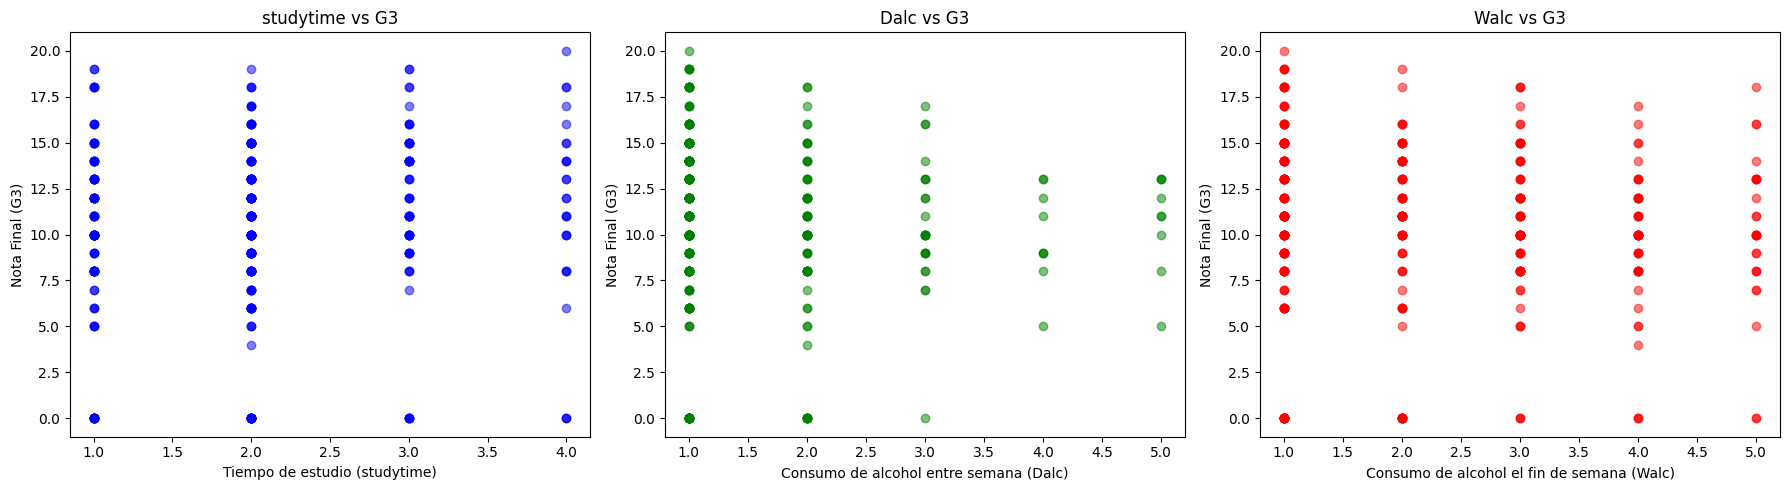

In [10]:
# Gráficos de dispersión para observar relaciones con la variable objetivo ('G3')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# studytime vs G3
axes[0].scatter(df_limpio["studytime"], df_limpio["G3"], alpha=0.5, color="blue")
axes[0].set_xlabel("Tiempo de estudio (studytime)")
axes[0].set_ylabel("Nota Final (G3)")
axes[0].set_title("studytime vs G3")

# Dalc vs G3
axes[1].scatter(df_limpio["Dalc"], df_limpio["G3"], alpha=0.5, color="green")
axes[1].set_xlabel("Consumo de alcohol entre semana (Dalc)")
axes[1].set_ylabel("Nota Final (G3)")
axes[1].set_title("Dalc vs G3")

# Walc vs G3
axes[2].scatter(df_limpio["Walc"], df_limpio["G3"], alpha=0.5, color="red")
axes[2].set_xlabel("Consumo de alcohol el fin de semana (Walc)")
axes[2].set_ylabel("Nota Final (G3)")
axes[2].set_title("Walc vs G3")

plt.tight_layout()
plt.show()

Matriz de correlación

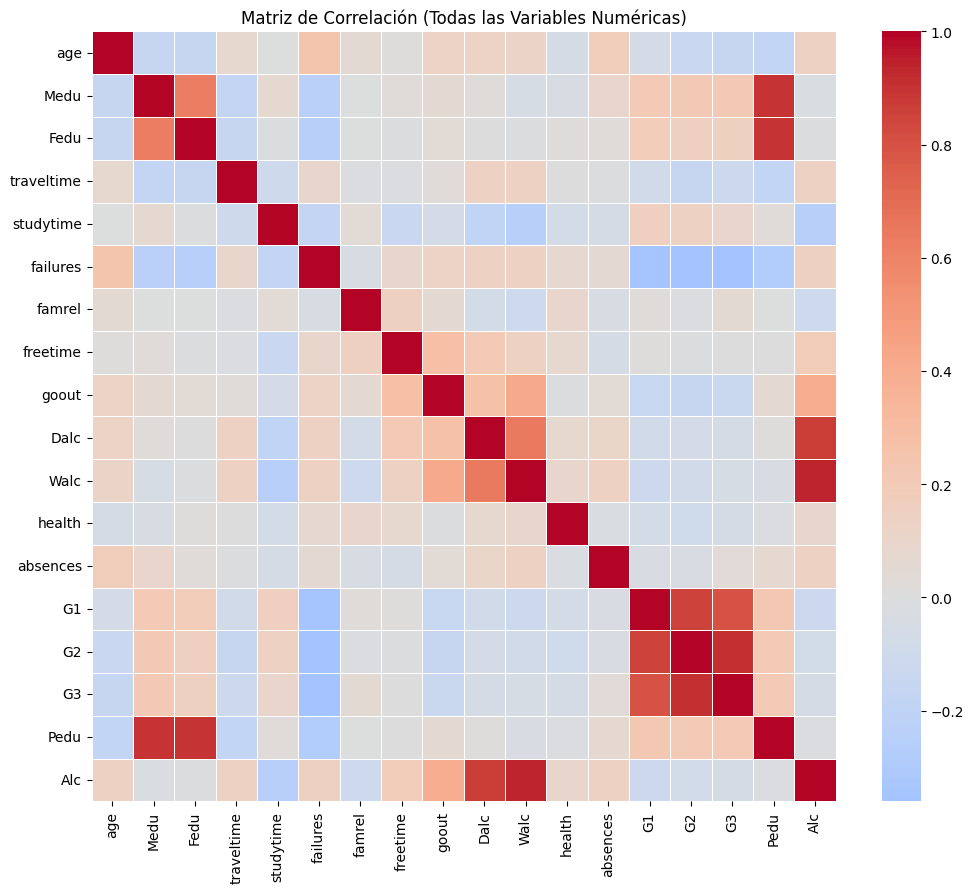


Correlación de todas las características numéricas con 'G3' (ordenadas de mayor a menor):
G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Pedu          0.205224
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
Alc          -0.058245
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64


In [11]:
import seaborn as sns

# Seleccionar todas las columnas numéricas de la base de datos
df_numerico = df_limpio.select_dtypes(include=["number"])

# Cálculo de la matriz de correlación completa
df_corr_completa = df_numerico.corr()

# Configurar el tamaño de la figura (ajustado para que se vean bien todas las variables)
plt.figure(figsize=(12, 10))
sns.heatmap(df_corr_completa, annot=False, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Matriz de Correlación (Todas las Variables Numéricas)")
plt.show()

# Mostrar la correlación ordenada de todas las variables con 'G3'
print("\nCorrelación de todas las características numéricas con 'G3' (ordenadas de mayor a menor):")
print(df_corr_completa["G3"].sort_values(ascending=False))

In [12]:
# Selección de las 4 características de entrada y variable objetivo
caracteristicas = ["Pedu", "Alc", "failures", "G1"]
X_raw = df_limpio[caracteristicas].values
y = df_limpio["G3"].values

# Agregar el término de sesgo (columna de unos para theta_0)
N = len(X_raw)
X_lineal = np.column_stack([np.ones(N), X_raw])

print("Forma de X para Regresión Lineal (con columna de unos):", X_lineal.shape)

Forma de X para Regresión Lineal (con columna de unos): (395, 5)


División en Train y Test

In [13]:
# Usamos la misma semilla para que los conjuntos de datos coincidan exactamente con la regresión polinómica
np.random.seed(42)

indices = np.arange(len(X_lineal))
np.random.shuffle(indices)

limite = int(len(X_lineal) * 0.8)
train_idx, test_idx = indices[:limite], indices[limite:]

X_train_lin, y_train_lin = X_lineal[train_idx], y[train_idx]
X_test_lin, y_test_lin = X_lineal[test_idx], y[test_idx]

print(f"Conjunto Train (Lineal): {len(X_train_lin)} muestras")
print(f"Conjunto Test (Lineal): {len(X_test_lin)} muestras")

Conjunto Train (Lineal): 316 muestras
Conjunto Test (Lineal): 79 muestras


Entrenamiento con Ecuación Normal y Métricas

In [14]:
# Entrenamiento usando Ecuación Normal: theta = (X^T * X)^(-1) * X^T * y
theta_lineal = np.linalg.inv(X_train_lin.T @ X_train_lin) @ X_train_lin.T @ y_train_lin

# Predicciones
y_pred_train_lin = X_train_lin @ theta_lineal
y_pred_test_lin = X_test_lin @ theta_lineal

# Funciones de evaluación (MAE y R2)
def calcular_mae(y_real, y_pred):
    return np.mean(np.abs(y_real - y_pred))

def calcular_r2(y_real, y_pred):
    ss_tot = np.sum((y_real - np.mean(y_real)) ** 2)
    ss_res = np.sum((y_real - y_pred) ** 2)
    return 1 - (ss_res / ss_tot)

mae_train_lin, r2_train_lin = calcular_mae(y_train_lin, y_pred_train_lin), calcular_r2(y_train_lin, y_pred_train_lin)
mae_test_lin, r2_test_lin = calcular_mae(y_test_lin, y_pred_test_lin), calcular_r2(y_test_lin, y_pred_test_lin)

print("--- REGRESIÓN LINEAL MÚLTIPLE ---")
print(f"Train -> MAE: {mae_train_lin:.4f} | R2: {r2_train_lin:.4f}")
print(f"Test  -> MAE: {mae_test_lin:.4f} | R2: {r2_test_lin:.4f}\n")

# Ecuación del modelo final
nombres_lineal = ["1", "Pedu", "Alc", "failures", "G1"]
ecuacion_lineal = "G3 = " + " + ".join([f"({coef:.4f} * {nombre})" for coef, nombre in zip(theta_lineal, nombres_lineal)])
print("Ecuación Final de Regresión Lineal:")
print(ecuacion_lineal)

--- REGRESIÓN LINEAL MÚLTIPLE ---
Train -> MAE: 1.8119 | R2: 0.6870
Test  -> MAE: 2.2053 | R2: 0.4703

Ecuación Final de Regresión Lineal:
G3 = (-1.9030 * 1) + (-0.0069 * Pedu) + (0.1439 * Alc) + (-0.3632 * failures) + (1.1139 * G1)


Visualización de resultados (Valores Reales vs Predichos)

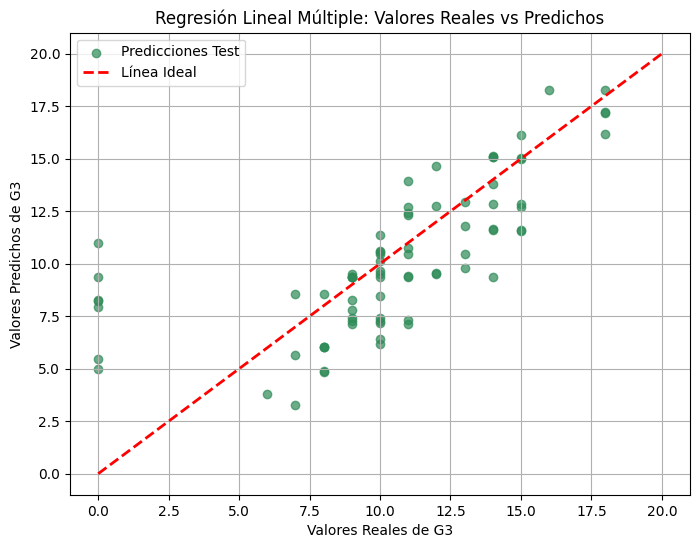

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_lin, y_pred_test_lin, color="seagreen", alpha=0.7, label="Predicciones Test")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label="Línea Ideal")

plt.xlabel("Valores Reales de G3")
plt.ylabel("Valores Predichos de G3")
plt.title("Regresión Lineal Múltiple: Valores Reales vs Predichos")
plt.legend()
plt.grid(True)
plt.show()

Exportar modelo

In [16]:
import joblib
from google.colab import files

# Guardar el vector de coeficientes theta obtenido por la Ecuación Normal
modelo_lineal_exportado = {"theta": theta_lineal}

# Exportar a un archivo .joblib
joblib.dump(modelo_lineal_exportado, "modelo_lineal.joblib")

# Descargar automáticamente a tu computadora
files.download("modelo_lineal.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>